In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
print(os.getcwd())

/content


This is the historical data that covers sales from 2010-02-05 to 2012-11-01, in the file Walmart_Store_sales. Within this file you will find the following fields:\

**Store** - the store number

**Date** - the week of sales

**Weekly_Sales** - sales for the given store
Holiday_Flag - whether the week is a special holiday week 1 – Holiday week 0 – Non-holiday week

**Temperature** - Temperature on the day of sale

**Fuel_Price** - Cost of fuel in the region

**CPI** – Prevailing consumer price index

**Unemployment** - Prevailing unemployment rate

**Holiday Events\

**Super Bowl**: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13\

 **Labour Day**: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13\

**Thanksgiving**: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13\


**Christmas:** 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

In [ ]:
from pathlib import Path

db = Path(r"")

# Load the dataset
df = pd.read_csv(db)

# Display the first few rows
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:

# Check for missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print("Missing values per column:\n", missing_values)

Missing values per column:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# Count the total number of duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_rows}")



Total duplicate rows: 0


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  02-05-2010    1643690.90             0        42.31       2.572   
1      1  02-12-2010    1641957.44             1        38.51       2.548   
2      1         NaN    1611968.17             0        39.93       2.514   
3      1         NaN    1409727.59             0        46.63       2.561   
4      1  03-05-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [ ]:

# Check unique date formats
unique_dates = df['Date'].astype(str).str.strip().unique()

# Display unique date formats
print("Unique date values (sample):")
print(unique_dates[:20])  # Show first 20 unique values
print(f"Total unique date values: {len(unique_dates)}")

# 143 weeks or 2 years 9 months


Unique date values (sample):
['05-02-2010' '12-02-2010' '19-02-2010' '26-02-2010' '05-03-2010'
 '12-03-2010' '19-03-2010' '26-03-2010' '02-04-2010' '09-04-2010'
 '16-04-2010' '23-04-2010' '30-04-2010' '07-05-2010' '14-05-2010'
 '21-05-2010' '28-05-2010' '04-06-2010' '11-06-2010' '18-06-2010']
Total unique date values: 143


In [ ]:
print(df['Date'].isna().sum())  # Count NaN values in Date column


0


In [3]:
# Reload original dataset
df_original = pd.read_csv(r"C:\Users\admin\Personal projects\walmart-sales-dataset-of-45stores.csv")

# Fill missing values in Date column with original values
df['Date'].fillna(df_original['Date'], inplace=True)

# Check if missing values are restored
print(df.isna().sum())  # Should show 0 missing dates


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\admin\\Personal projects\\walmart-sales-dataset-of-45stores.csv'

In [ ]:
df['Date'].fillna(df_original['Date'], inplace=True)


C:\Users\admin\AppData\Local\Temp\ipykernel_18272\2084058950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Date'].fillna(df_original['Date'], inplace=True)


In [ ]:
df['Date'] = df['Date'].fillna(df_original['Date'])


In [ ]:
# Verify if NaN values were restored
print(df.isna().sum())  # Should show 0 missing dates

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
print(len(df))


6435


In [ ]:
# Display unique date samples
unique_dates = df['Date'].astype(str).unique()

# Show first 20 unique dates
print("Unique date values (sample):")
print(unique_dates[:20])

# Count total unique date formats
print(f"Total unique dates: {len(unique_dates)}")


Unique date values (sample):
['05-02-2010' '12-02-2010' '19-02-2010' '26-02-2010' '05-03-2010'
 '12-03-2010' '19-03-2010' '26-03-2010' '02-04-2010' '09-04-2010'
 '16-04-2010' '23-04-2010' '30-04-2010' '07-05-2010' '14-05-2010'
 '21-05-2010' '28-05-2010' '04-06-2010' '11-06-2010' '18-06-2010']
Total unique dates: 143


In [ ]:
import re

# Function to detect date pattern
def detect_date_pattern(date):
    date = str(date).strip()

    if re.match(r"^\d{2}-\d{2}-\d{4}$", date):  # Expected format: dd-mm-yyyy
        return "dd-mm-yyyy"
    elif re.match(r"^\d{4}-\d{2}-\d{2}$", date):  # yyyy-mm-dd
        return "yyyy-mm-dd"
    elif re.match(r"^\d{1,2}/\d{1,2}/\d{4}$", date):  # d/m/yyyy
        return "d/m/yyyy or similar"
    else:
        return "Unknown Format"

# Apply function to dataset
df['Date'] = df['Date'].astype(str).apply(detect_date_pattern)

# Count occurrences of each format
print("Different date formats in dataset:")
print(df['Date_Format'].value_counts())


Different date formats in dataset:
Date
Unknown Format    6435
Name: count, dtype: int64


In [ ]:
df['Date'] = df_original['Date']

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Convert back to 'dd-mm-yyyy' string format
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

# Verify if all dates are correctly formatted
print(df[['Date']].head(10))


         Date
0  05-02-2010
1  12-02-2010
2  19-02-2010
3  26-02-2010
4  05-03-2010
5  12-03-2010
6  19-03-2010
7  26-03-2010
8  02-04-2010
9  09-04-2010


In [ ]:
#Check for Any Remaining NaN Dates
#After conversion, some invalid date formats may turn into NaT (Not a Time). Let's check:
missing_dates = df[df['Date'].isna()]
print("Rows with missing dates after conversion:")
print(missing_dates)


Rows with missing dates after conversion:
Empty DataFrame
Columns: [Store, Date, Weekly_Sales, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment]
Index: []


In [ ]:
df.to_csv(r"C:\Users\admin\Personal projects\walmart-sales-cleaned.csv", index=False)


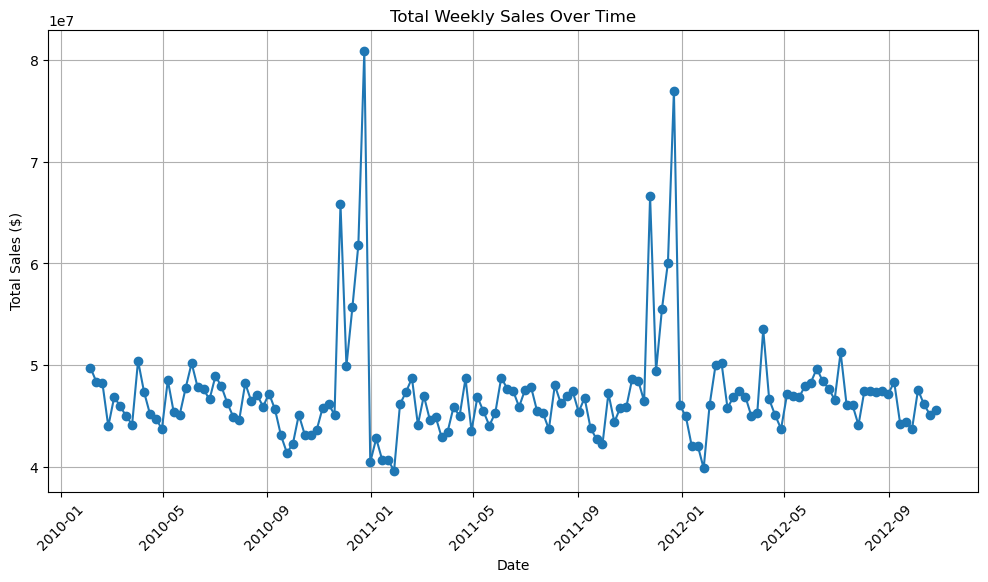

In [ ]:
import matplotlib.pyplot as plt

# Convert Date back to datetime for plotting
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Plot overall sales trend
plt.figure(figsize=(12, 6))
plt.plot(df.groupby('Date')['Weekly_Sales'].sum(), marker='o', linestyle='-')

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
import pandas as pd

# Convert Date column to datetime (if not already)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Define holiday mapping
holiday_dict = {
    '12-02-2010': 'Super Bowl', '11-02-2011': 'Super Bowl', '10-02-2012': 'Super Bowl',
    '10-09-2010': 'Labour Day', '09-09-2011': 'Labour Day', '07-09-2012': 'Labour Day',
    '26-11-2010': 'Thanksgiving', '25-11-2011': 'Thanksgiving', '23-11-2012': 'Thanksgiving',
    '31-12-2010': 'Christmas', '30-12-2011': 'Christmas', '28-12-2012': 'Christmas'
}

# Convert dictionary keys to datetime format
holiday_dates = {pd.to_datetime(k, dayfirst=True): v for k, v in holiday_dict.items()}

# Create a new column with holiday names
df['Holiday_Name'] = df['Date'].map(holiday_dates)

# Fill non-holiday days with 'None'
df['Holiday_Name'] = df['Holiday_Name'].fillna('None')

# Verify holiday column
print(df[['Date', 'Holiday_Name']].head(15))



         Date Holiday_Name
0  2010-02-05         None
1  2010-02-12   Super Bowl
2  2010-02-19         None
3  2010-02-26         None
4  2010-03-05         None
5  2010-03-12         None
6  2010-03-19         None
7  2010-03-26         None
8  2010-04-02         None
9  2010-04-09         None
10 2010-04-16         None
11 2010-04-23         None
12 2010-04-30         None
13 2010-05-07         None
14 2010-05-14         None


In [ ]:
# Group by Holiday Name and calculate average sales
holiday_sales = df.groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False)

print("Average Sales During Holidays vs. Non-Holidays:")
print(holiday_sales)


Average Sales During Holidays vs. Non-Holidays:
Holiday_Name
Thanksgiving    1.471273e+06
Super Bowl      1.079128e+06
Labour Day      1.042427e+06
None            1.041256e+06
Christmas       9.608331e+05
Name: Weekly_Sales, dtype: float64


C:\Users\admin\AppData\Local\Temp\ipykernel_18272\2500523341.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_holiday_sales, x='Holiday_Name', y='Weekly_Sales', palette="viridis")


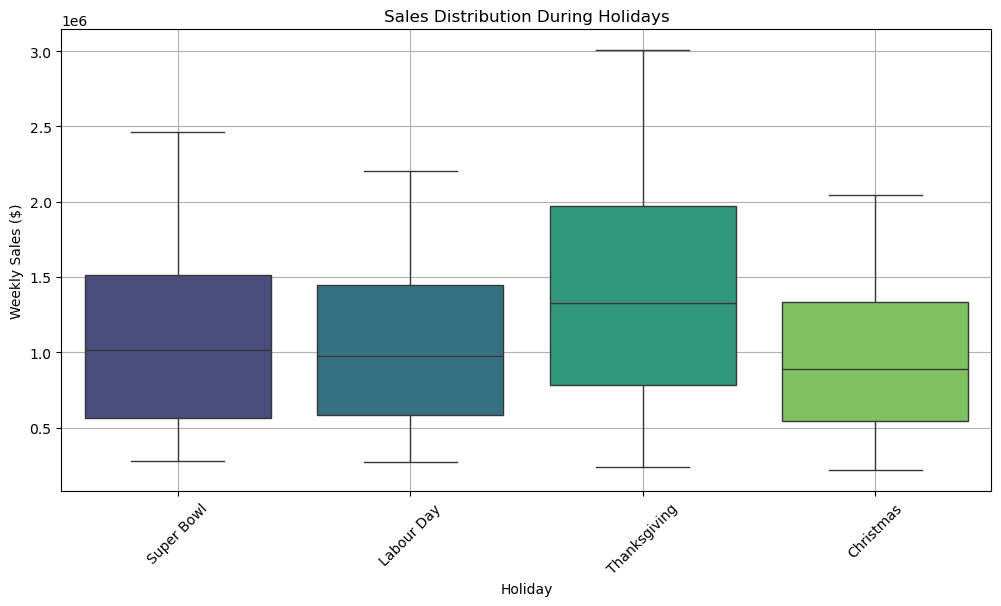

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only holiday sales
df_holiday_sales = df[df['Holiday_Name'] != 'None']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_holiday_sales, x='Holiday_Name', y='Weekly_Sales', palette="viridis")

plt.title("Sales Distribution During Holidays")
plt.xlabel("Holiday")
plt.ylabel("Weekly Sales ($)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
# Extract year from date
df['Year'] = df['Date'].dt.year

# Calculate average sales for each holiday per year
holiday_sales_yearly = df[df['Holiday_Name'] != 'None'].groupby(['Year', 'Holiday_Name'])['Weekly_Sales'].mean().unstack()

# Display holiday sales trends
print(holiday_sales_yearly)


Holiday_Name     Christmas    Labour Day    Super Bowl  Thanksgiving
Year                                                                
2010          8.985004e+05  1.014098e+06  1.074148e+06  1.462689e+06
2011          1.023166e+06  1.039183e+06  1.051915e+06  1.479858e+06
2012                   NaN  1.074001e+06  1.111320e+06           NaN


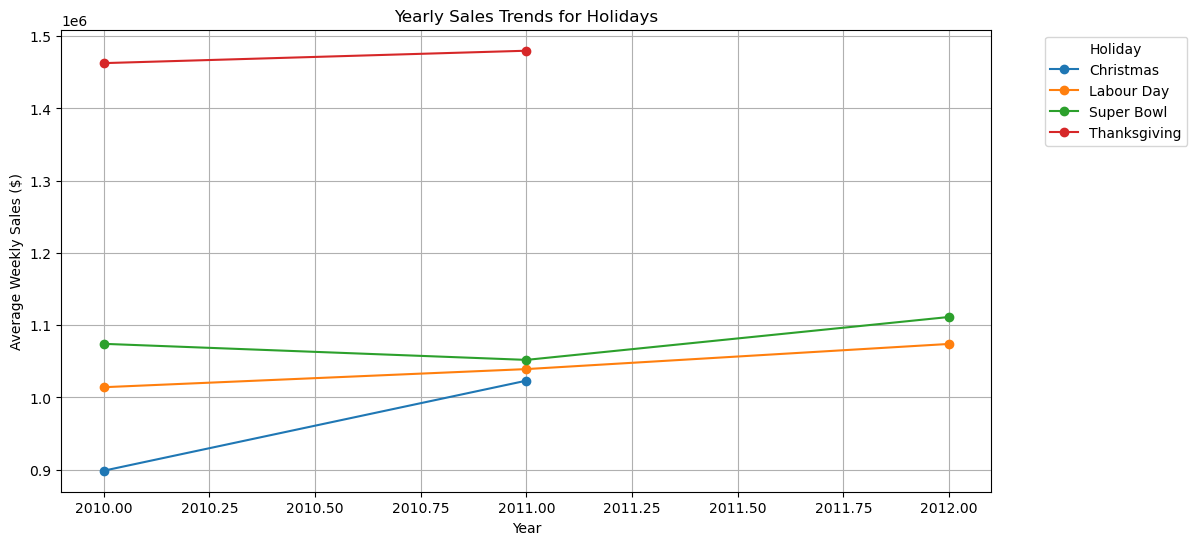

In [ ]:
import matplotlib.pyplot as plt

# Plot trends
holiday_sales_yearly.plot(kind='line', marker='o', figsize=(12, 6))

plt.title("Yearly Sales Trends for Holidays")
plt.xlabel("Year")
plt.ylabel("Average Weekly Sales ($)")
plt.legend(title="Holiday", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()


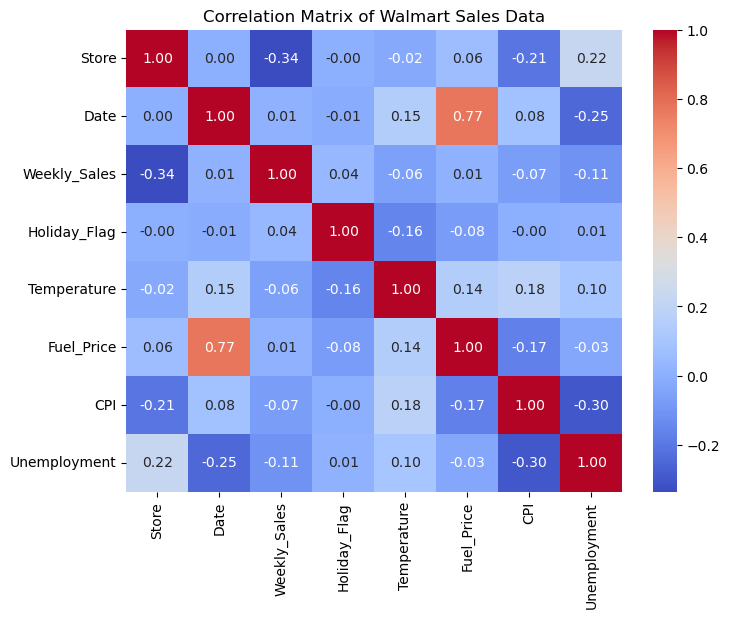

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\admin\Personal projects\walmart-sales-dataset-of-45stores.csv")

# Convert Date to datetime (if applicable)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Calculate correlation matrix
correlation_matrix = df.corr()

# Display correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Walmart Sales Data")
plt.show()


In [ ]:
import pandas as pd

# Load dataset (assuming it's in a CSV file)
df = pd.read_csv("walmart-sales-cleaned.csv")

# Create a new column that sums up all weekly sales per store
df["total_store_sales"] = df.groupby("Store")["Weekly_Sales"].transform("sum")

# Save the updated dataset
df.to_csv("walmart-sales-cleaned.csv", index=False)

# Display the first few rows
print(df.head())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  total_store_sales  
0  211.096358         8.106       2.224028e+08  
1  211.242170         8.106       2.224028e+08  
2  211.289143         8.106       2.224028e+08  
3  211.319643         8.106       2.224028e+08  
4  211.350143         8.106       2.224028e+08  


In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,total_store_sales
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,2.224028e+08
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106,2.224028e+08
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106,2.224028e+08
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106,2.224028e+08
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106,2.224028e+08


In [ ]:
# Extract year from date
df['total_store_sales'] = maxdf['total_store_sales'].dt.year